In [3]:
# Load the data from part 1 
import pickle
import pandas as pd
import networkx as nx

# disease-level ppi
with open("../data/ppi.pkl", "rb") as f:
    ppi = pickle.load(f)

# species full biogrid ppi
with open("../data/biogrid.pkl", "rb") as f:
    biogrid = pickle.load(f)

# human to other organism mapping
mapping = pd.read_csv("../data/homolog_mapping.csv")

# networks
with open("../data/networks.pkl", "rb") as f:
    networks = pickle.load(f)

# hubs
with open("../data/hubs.pkl", "rb") as f:
    hubs = pickle.load(f)

In [4]:
diseases = list(networks.keys())

# human is reference
target_species = ["mouse", "yeast", "fly"]

In [5]:
print("Diseases:", diseases)
print("Sanity check for AD human:", networks["AD"]["human"])

Diseases: ['AD', 'PD', 'COVID', 'BC']
Sanity check for AD human: Graph with 4310 nodes and 7594 edges


In [6]:
def collapse_case_duplicates(G):
    """Merge nodes that differ only in case. Keeps the highest-degree variant as canonical."""
    lower_to_nodes = {}
    for n in G.nodes():
        lower_to_nodes.setdefault(n.lower(), []).append(n)
    
    rename_map = {}
    for low, nodes in lower_to_nodes.items():
        if len(nodes) > 1:
            canonical = max(nodes, key=lambda n: G.degree(n))
            for n in nodes:
                if n != canonical:
                    rename_map[n] = canonical
    
    if rename_map:
        return nx.relabel_nodes(G, rename_map, copy=True)
    return G

# Apply to all networks
for d in diseases:
    for sp in networks[d].keys():
        before = networks[d][sp].number_of_nodes()
        networks[d][sp] = collapse_case_duplicates(networks[d][sp])
        after = networks[d][sp].number_of_nodes()
        if before != after:
            print(f"{d}/{sp}: {before}; {after} nodes ({before-after} merged)")

AD/human: 4310; 4241 nodes (69 merged)
AD/mouse: 3237; 3084 nodes (153 merged)
AD/fly: 1380; 1377 nodes (3 merged)
PD/human: 3168; 3107 nodes (61 merged)
PD/mouse: 2174; 2056 nodes (118 merged)
PD/fly: 1204; 1202 nodes (2 merged)
COVID/human: 1088; 1085 nodes (3 merged)
COVID/mouse: 236; 234 nodes (2 merged)
BC/human: 2879; 2860 nodes (19 merged)
BC/mouse: 1924; 1864 nodes (60 merged)
BC/fly: 1583; 1568 nodes (15 merged)


In [7]:
# Cluster the human network
from networkx.algorithms.community import louvain_communities

RANDOM_SEED = 42
MIN_MODULE_SIZE = 5

def find_modules(G, min_size=MIN_MODULE_SIZE, seed=RANDOM_SEED):
    communities = louvain_communities(G, seed=seed)
    return [set(c) for c in communities if len(c) >= min_size]

modules = {d: find_modules(networks[d]["human"]) for d in diseases}

for d in diseases:
    sizes = [len(m) for m in modules[d]]
    print(f"{d}: {len(modules[d])} modules (>{MIN_MODULE_SIZE} nodes), "
          f"sizes {min(sizes)};{max(sizes)}")

AD: 23 modules (>5 nodes), sizes 17;504
PD: 23 modules (>5 nodes), sizes 5;316
COVID: 22 modules (>5 nodes), sizes 5;234
BC: 22 modules (>5 nodes), sizes 6;396


In [8]:
species_cols = {
    "mouse": "Mouse gene name",
    "yeast": "Saccharomyces cerevisiae gene name",
    "fly":   "Drosophila melanogaster - (Fruit fly) gene name",
}

def get_orthologs(human_gene, species):
    """Return set of orthologs for a human gene in the target species."""
    col = species_cols[species]
    matches = mapping[mapping["Gene name"].str.upper() == human_gene.upper()][col]
    return set(matches.dropna().tolist())

In [9]:
def node_conservation(module, species):
    """Fraction of human genes in the module that have an ortholog in target species."""
    if not module:
        return None
    has_ortholog = sum(1 for g in module if len(get_orthologs(g, species)) > 0)
    return has_ortholog / len(module)

In [10]:
def edge_conservation(module, G_human_disease, species, G_target_disease):
    """
    Returns (score, edges_evaluated, edges_conserved).
    Only edges where BOTH endpoints have at least one ortholog are evaluated.
    Edge counts as conserved if ANY pair of orthologs is connected in the target.
    """
    H = G_human_disease.subgraph(module)
    edges_evaluated = 0
    edges_conserved = 0
    for u, v in H.edges():
        u_orthos = get_orthologs(u, species)
        v_orthos = get_orthologs(v, species)
        if not u_orthos or not v_orthos:
            continue  # at least one endpoint can't be mapped - skip
        edges_evaluated += 1
        if any(G_target_disease.has_edge(uo, vo) for uo in u_orthos for vo in v_orthos):
            edges_conserved += 1
    score = edges_conserved / edges_evaluated if edges_evaluated > 0 else None
    return score, edges_evaluated, edges_conserved

In [11]:
def topology_conservation(module, G_human_disease, species, G_target_disease):
    H = G_human_disease.subgraph(module)
    if H.number_of_nodes() < 2 or H.number_of_edges() == 0:
        return None

    # Get all orthologs of the module's genes
    target_nodes = set()
    for g in module:
        target_nodes.update(get_orthologs(g, species))
    if len(target_nodes) < 2:
        return 0.0
    T = G_target_disease.subgraph(target_nodes)

    # Density ratio (capped at 1)
    d_h = nx.density(H)
    d_t = nx.density(T)
    density_ratio = min(d_t / d_h, 1.0) if d_h > 0 else None

    # Edge Jaccard over ortholog-pair representations
    human_edges_mapped = set()
    for u, v in H.edges():
        u_orthos = get_orthologs(u, species)
        v_orthos = get_orthologs(v, species)
        for uo in u_orthos:
            for vo in v_orthos:
                if uo != vo:
                    human_edges_mapped.add(frozenset((uo, vo)))

    target_edges = {frozenset(e) for e in T.edges()}

    if not human_edges_mapped and not target_edges:
        jaccard = None
    else:
        intersection = len(human_edges_mapped & target_edges)
        union = len(human_edges_mapped | target_edges)
        jaccard = intersection / union if union > 0 else 0.0

    parts = [x for x in [density_ratio, jaccard] if x is not None]
    return sum(parts) / len(parts) if parts else None

In [12]:
rows = []
for d in diseases:
    G_h = networks[d]["human"]
    print(f"Processing {d}...")
    for module_idx, module in enumerate(modules[d]):
        for sp in target_species:
            G_t = networks[d][sp]

            n_score = node_conservation(module, sp)
            e_score, n_eval, n_cons = edge_conservation(module, G_h, sp, G_t)
            t_score = topology_conservation(module, G_h, sp, G_t)

            rows.append({
                "disease": d, "species": sp,
                "module_id": module_idx, "module_size": len(module),
                "node_conservation": n_score,
                "edge_conservation": e_score,
                "edges_evaluated": n_eval,
                "edges_conserved": n_cons,
                "topology_conservation": t_score,
            })

scores_df = pd.DataFrame(rows)
scores_df.to_csv("../data/conservation_scores.csv", index=False)
scores_df.head(15)

Processing AD...
Processing PD...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def weighted_mean(values, weights):
    mask = ~values.isna()
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

# Aggregate
agg_rows = []
for (d, sp), grp in scores_df.groupby(["disease", "species"]):
    w = grp["module_size"]
    node_c = weighted_mean(grp["node_conservation"], w)
    edge_c = weighted_mean(grp["edge_conservation"], w)
    topo_c = weighted_mean(grp["topology_conservation"], w)
    parts = [x for x in [node_c, edge_c, topo_c] if not pd.isna(x)]
    agg_rows.append({
        "disease": d, "species": sp,
        "node_conservation": node_c,
        "edge_conservation": edge_c,
        "topology_conservation": topo_c,
        "transferability": np.mean(parts) if parts else np.nan,
    })

agg_df = pd.DataFrame(agg_rows)
agg_df.to_csv("../data/transferability_summary.csv", index=False)
print(agg_df)

   disease species  node_conservation  edge_conservation  \
0       AD     fly           0.529565           0.055300   
1       AD   mouse           0.902554           0.083849   
2       AD   yeast           0.254021           0.286224   
3       BC     fly           0.545136           0.055510   
4       BC   mouse           0.914626           0.058901   
5       BC   yeast           0.257873           0.167648   
6    COVID     fly           0.562264           0.006838   
7    COVID   mouse           0.897170           0.028915   
8    COVID   yeast           0.263208           0.000000   
9       PD     fly           0.565584           0.098111   
10      PD   mouse           0.908766           0.118205   
11      PD   yeast           0.300000           0.243868   

    topology_conservation  transferability  
0                0.387610         0.324158  
1                0.410527         0.465643  
2                0.448649         0.329631  
3                0.398365         0.333

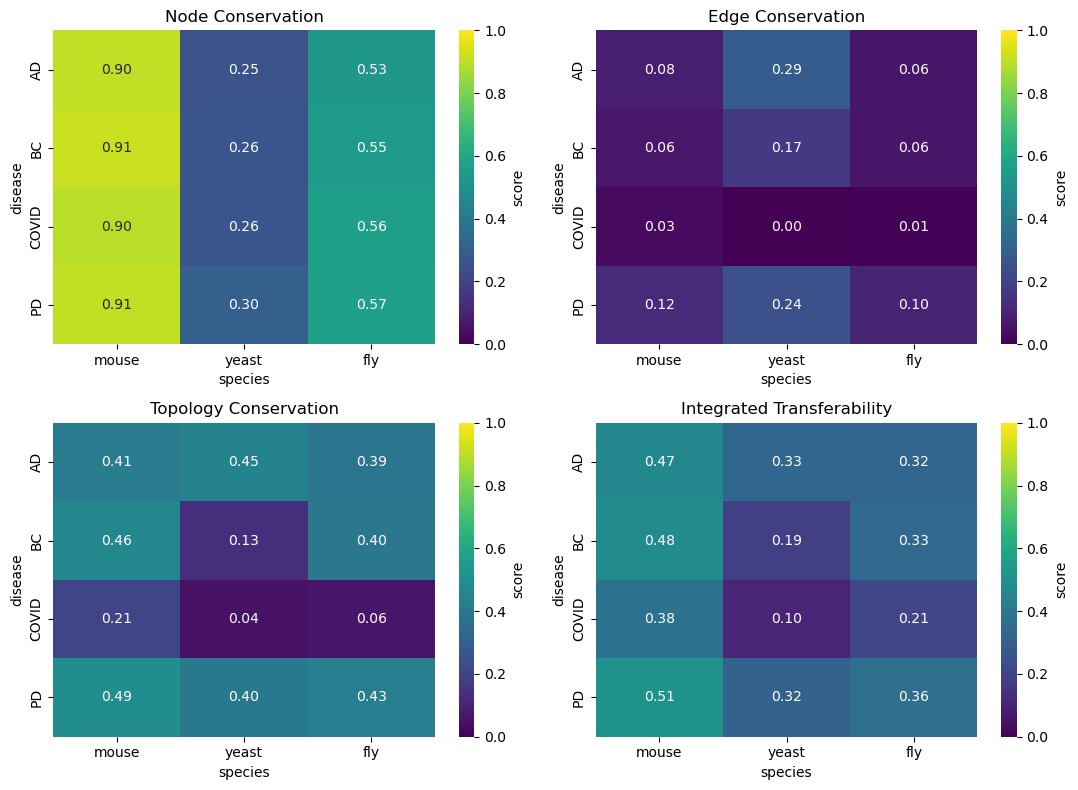

In [ ]:
metrics = ["node_conservation", "edge_conservation", "topology_conservation", "transferability"]
titles = ["Node Conservation", "Edge Conservation", "Topology Conservation", "Integrated Transferability"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, metric, title in zip(axes.flat, metrics, titles):
    pivot = agg_df.pivot(index="disease", columns="species", values=metric)
    pivot = pivot[target_species]  # consistent column order: mouse, yeast, fly
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis",
                vmin=0, vmax=1, ax=ax, cbar_kws={"label": "score"})
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../figures/conservation_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
def collect_conserved_nodes(diseases, target_species, modules, networks):
    rows = []
    for d in diseases:
        for sp in target_species:
            G_target = networks[d][sp]
            target_node_set = set(G_target.nodes())
            for module_idx, module in enumerate(modules[d]):
                for human_gene in module:
                    orthos = get_orthologs(human_gene, sp)
                    # Which orthologs are actually in the target disease network?
                    present = orthos & target_node_set
                    if present:
                        rows.append({
                            "disease": d, "species": sp,
                            "module_id": module_idx,
                            "human_gene": human_gene,
                            "ortholog_in_network": ", ".join(sorted(present)),
                            "degree_in_target": max(G_target.degree(o) for o in present),
                        })
    return pd.DataFrame(rows)

conserved_nodes = collect_conserved_nodes(diseases, target_species, modules, networks)

# Top 20 conserved nodes per (disease, species), ranked by degree in target network
for d in diseases:
    for sp in target_species:
        sub = conserved_nodes[(conserved_nodes["disease"] == d) &
                              (conserved_nodes["species"] == sp)]
        top = sub.nlargest(20, "degree_in_target")[
            ["human_gene", "ortholog_in_network", "degree_in_target"]
        ]
        print(f"({d}, {sp}): top 20 conserved nodes by target degree")
        print(top.to_string(index=False))

conserved_nodes.to_csv("../data/conserved_nodes.csv", index=False)

(AD, mouse): top 20 conserved nodes by target degree
human_gene ortholog_in_network  degree_in_target
      BIN1                Bin1              1096
      MAPT                Mapt               337
    ADAM10              Adam10               202
    KCNMA1              Kcnma1               185
       APP                 App               179
       VCP                 Vcp               158
    DPYSL2              Dpysl2               148
    GRIN2B              Grin2b               134
     GSK3B               Gsk3b               107
     CD2AP               Cd2ap                95
     PPARG               Pparg                80
    UQCRC1              Uqcrc1                74
      PRNP                Prnp                65
     GAPDH               Gapdh                62
    PIK3R1              Pik3r1                61
       GRN                 Grn                60
      TPI1                Tpi1                59
     NTRK2               Ntrk2                55
     NCSTN      

In [ ]:
def collect_conserved_edges(diseases, target_species, modules, networks):
    rows = []
    for d in diseases:
        G_h = networks[d]["human"]
        for sp in target_species:
            G_t = networks[d][sp]
            for module_idx, module in enumerate(modules[d]):
                H = G_h.subgraph(module)
                for u, v in H.edges():
                    u_orthos = get_orthologs(u, sp)
                    v_orthos = get_orthologs(v, sp)
                    if not u_orthos or not v_orthos:
                        continue
                    # Find which specific ortholog pair is connected
                    conserved_pairs = [
                        (uo, vo) for uo in u_orthos for vo in v_orthos
                        if G_t.has_edge(uo, vo)
                    ]
                    if conserved_pairs:
                        rows.append({
                            "disease": d, "species": sp,
                            "module_id": module_idx,
                            "human_edge": f"{u} - {v}",
                            "target_edge": "; ".join(f"{a}-{b}" for a, b in conserved_pairs),
                        })
    return pd.DataFrame(rows)

conserved_edges = collect_conserved_edges(diseases, target_species, modules, networks)
conserved_edges.to_csv("../data/conserved_edges.csv", index=False)

# Print summary: how many conserved edges per (disease, species)
print(conserved_edges.groupby(["disease", "species"]).size().unstack(fill_value=0))

# Print first 15 conserved edges per (disease, species) for spot-checking
for d in diseases:
    for sp in target_species:
        sub = conserved_edges[(conserved_edges["disease"] == d) &
                              (conserved_edges["species"] == sp)]
        print(f"({d}, {sp}): first 15 conserved edges")
        print(sub.head(15)[["human_edge", "target_edge"]].to_string(index=False))

species  fly  mouse  yeast
disease                   
AD        86    381     90
BC        58    161     39
COVID      2     28      0
PD       229    438    229
(AD, mouse): first 15 conserved edges
     human_edge   target_edge
    CPEB1 - APP     Cpeb1-App
  APBB1 - APLP2   Apbb1-Aplp2
 APBB1 - Rnf157  Apbb1-Rnf157
  GSTP1 - MAPK8   Gstp2-Mapk8
  GSTP1 - FANCC   Gstp1-Fancc
  GSTP1 - PRDX6   Gstp1-Prdx6
 AP2B1 - PICALM  Ap2b1-Picalm
  CLTC - PICALM   Cltc-Picalm
  MAPK8 - APBB2   Mapk8-Apbb2
   MAPK8 - WWOX    Mapk8-Wwox
   PRDX6 - NCF2    Prdx6-Ncf2
MAPK8IP2 - LRP8 Mapk8ip2-Lrp8
LRP8 - MAPK8IP1 Lrp8-Mapk8ip1
   UCHL5 - CTSD    Uchl5-Ctsd
   POR - PGRMC1    Por-Pgrmc1
(AD, yeast): first 15 conserved edges
      human_edge                                            target_edge
 CLTCL1 - PICALM                             CHC1-YAP1801; CHC1-YAP1802
   CLTC - PICALM                             CHC1-YAP1801; CHC1-YAP1802
PGRMC1 - CYP51A1                                             DAP1-

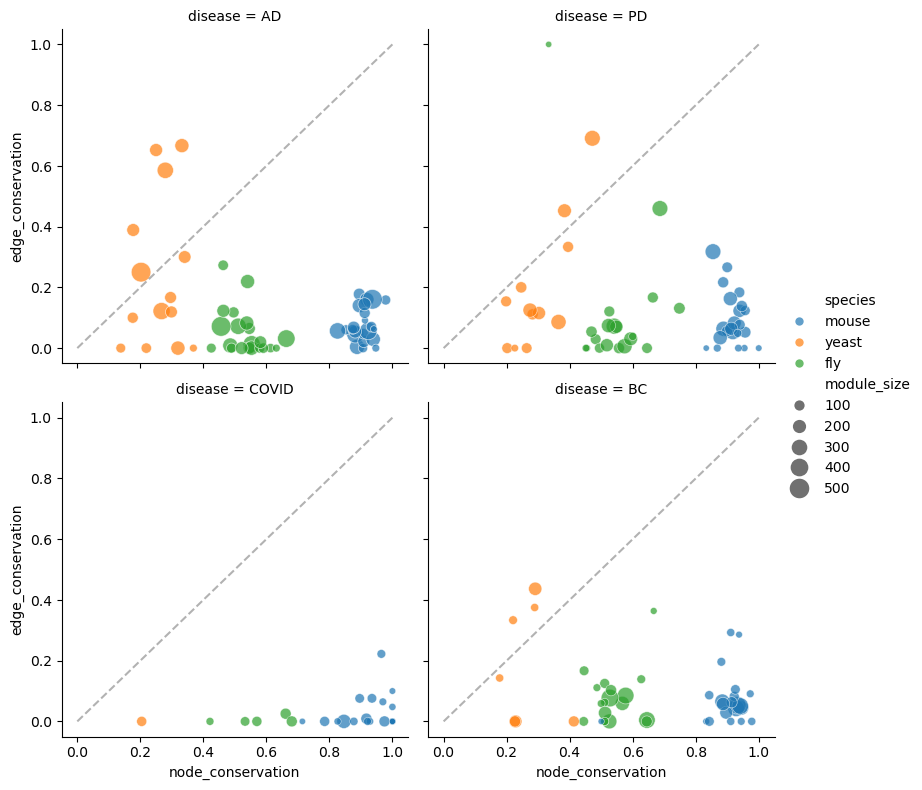

In [ ]:
import seaborn as sns
g = sns.relplot(
    data=scores_df, x="node_conservation", y="edge_conservation",
    hue="species", col="disease", col_wrap=2,
    size="module_size", sizes=(20, 200), alpha=0.7, height=4
)
g.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
for ax in g.axes.flat:
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)  # y=x diagonal
plt.savefig("../figures/node_vs_edge_scatter.png", dpi=200, bbox_inches="tight")

Text(0.5, 1.0, 'Module size distribution per disease')

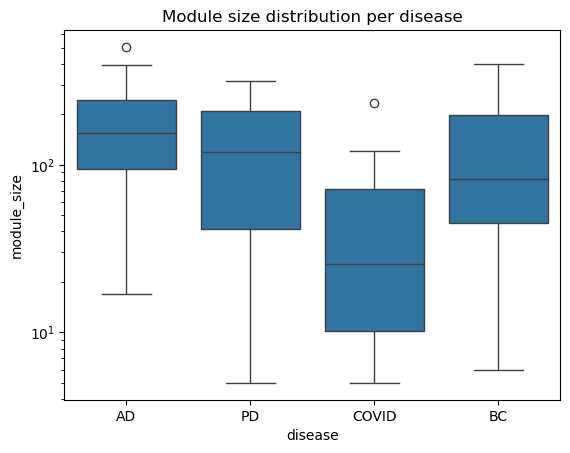

In [ ]:
sns.boxplot(data=scores_df.drop_duplicates(["disease","module_id"]),
            x="disease", y="module_size")
plt.yscale("log")
plt.title("Module size distribution per disease")

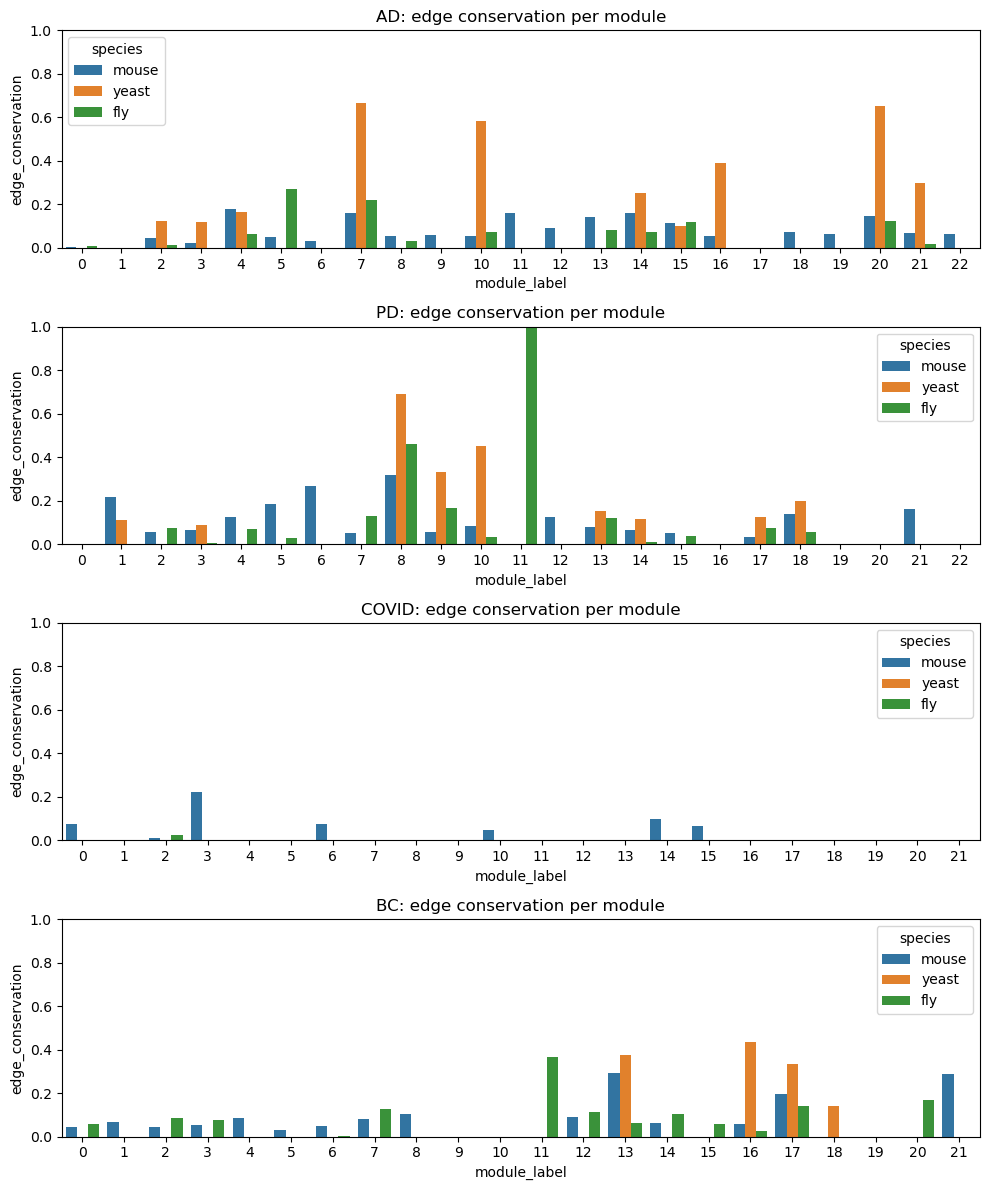

In [ ]:
fig, axes = plt.subplots(len(diseases), 1, figsize=(10, 3*len(diseases)), sharex=False)
for ax, d in zip(axes, diseases):
    sub = scores_df[scores_df["disease"] == d].copy()
    sub["module_label"] = sub["module_id"].astype(str)
    sns.barplot(data=sub, x="module_label", y="edge_conservation",
                hue="species", ax=ax)
    ax.set_title(f"{d}: edge conservation per module")
    ax.set_ylim(0, 1)
plt.tight_layout()

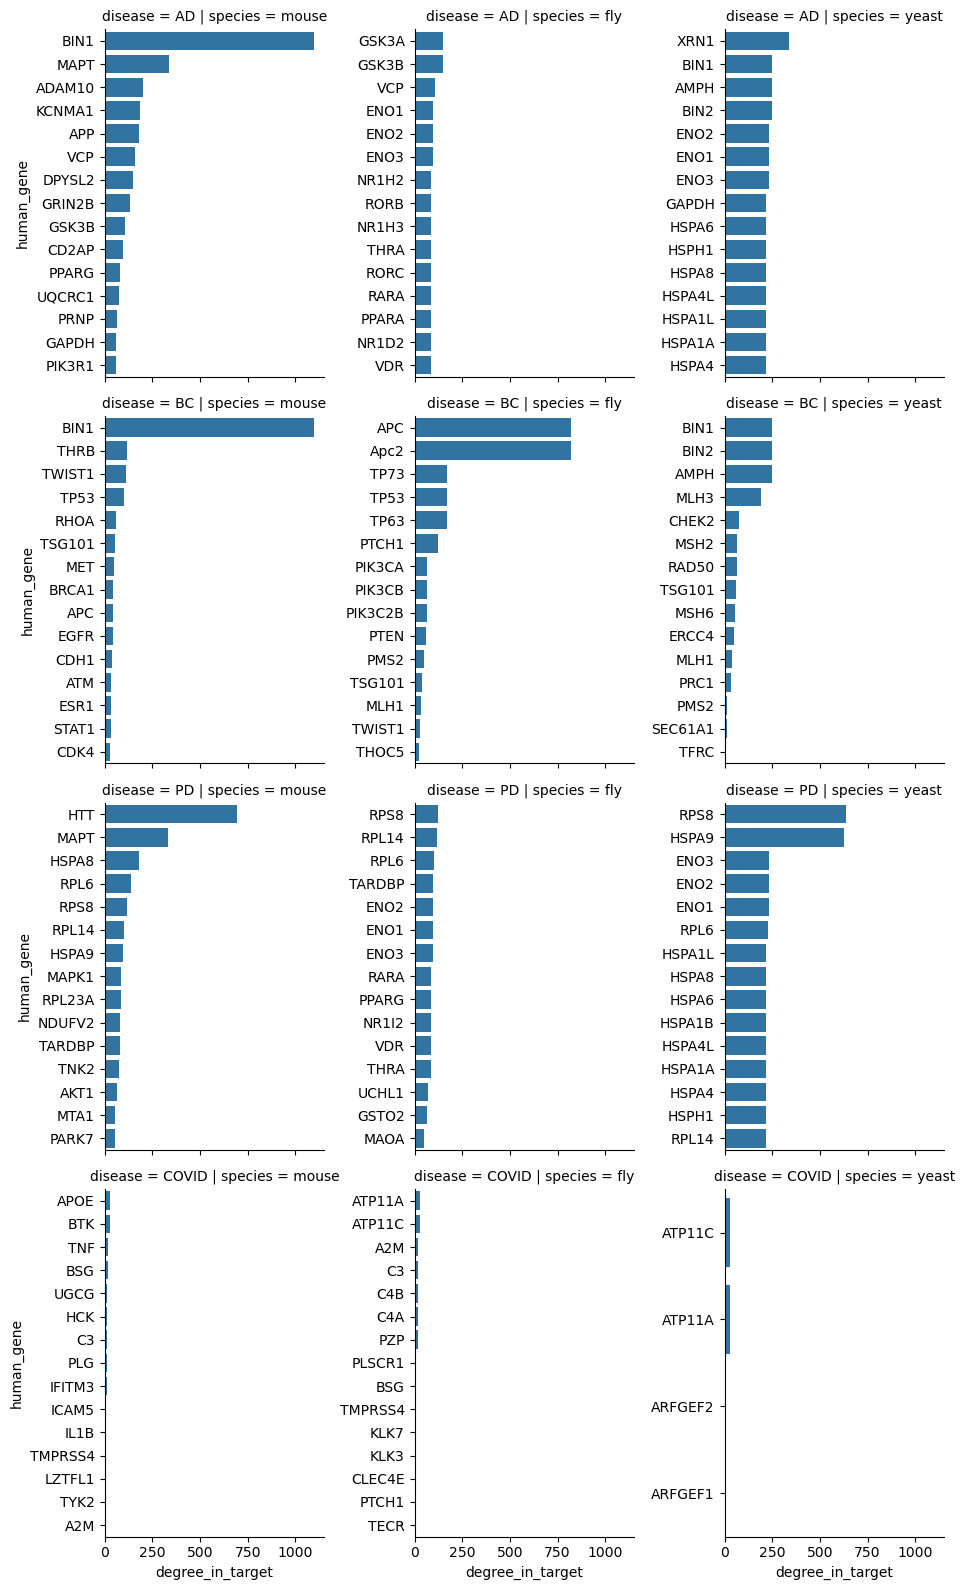

In [ ]:
# Per (disease, species), top 15 conserved nodes by target degree
top = (conserved_nodes
       .sort_values("degree_in_target", ascending=False)
       .groupby(["disease", "species"]).head(15))
g = sns.catplot(data=top, kind="bar",
                x="degree_in_target", y="human_gene",
                col="species", row="disease",
                sharey=False, height=4, aspect=0.8)
plt.savefig("../figures/top_conserved_hubs.png", dpi=200, bbox_inches="tight")